# Unsupervised Learning Task: PCA and Clustering on the US Arrests Dataset

In [8]:
# pandas: used for data manipulation and analysis (DataFrames, data cleaning, file I/O)
import pandas as pd  

# numpy: provides numerical computing support (arrays, mathematical operations)
import numpy as np  

# matplotlib.pyplot: used for creating visualizations such as plots and charts
import matplotlib.pyplot as plt  

# Make plots appear inline in Jupyter
%matplotlib inline

# seaborn: built on matplotlib; used for more advanced and visually appealing statistical plots
import seaborn as sns 

# StandardScaler: standardizes features by removing the mean and scaling to unit variance
from sklearn.preprocessing import StandardScaler  

# PCA (Principal Component Analysis): reduces dimensionality by transforming data into principal components
from sklearn.decomposition import PCA  

# KMeans: partitions data into k clusters based on similarity (centroid-based clustering)
# AgglomerativeClustering: hierarchical clustering method that merges data points into clusters step-by-step
from sklearn.cluster import KMeans, AgglomerativeClustering  

# silhouette_score: evaluates clustering quality (how well-separated and cohesive clusters are)
from sklearn.metrics import silhouette_score  

# linkage: computes hierarchical clustering linkage matrix (used to determine cluster merging)
# dendrogram: visualizes hierarchical clustering as a tree diagram
# fcluster: extracts flat clusters from a hierarchical clustering tree
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster  

# Improve table display
pd.set_option("display.max_columns", None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [9]:
# Load UsArrests dataset
df = pd.read_csv("UsArrests.csv",index_col=0)
df.head()

,Murder,Assault,UrbanPop,Rape
City,,,,
Alabama,13.20,236,58,21.20
Alaska,10.00,263,48,44.50
Arizona,8.10,294,80,31.00
Arkansas,8.80,190,50,19.50
California,9.00,276,91,40.60


## Data Preprocessing
Cleaned missing values and scaled features to ensure fair clustering performance.

In [10]:
# Check dataframe shape
df.shape

(50, 4)

In [11]:
# Summarize dataframe ['Unique', 'Missing (IsNull)', 'Nan (isNA)', 'Dtype']
summary = pd.DataFrame({
    'Unique': df.nunique(),
    'Missing (isNULL)': df.isnull().sum(),
    'NaN (isNA)': df.isna().sum(),
    ' ': '',   # blank column
    'Dtype': df.dtypes
})

print(summary.iloc[0:5])

          Unique  Missing (isNULL)  NaN (isNA)      Dtype
Murder        43                 0           0    float64
Assault       45                 0           0      int64
UrbanPop      36                 0           0      int64
Rape          48                 0           0    float64


### Initial observations

- The dataset has **50 rows** and **5 columns**.
- There are **no missing values**, therefore no imputation is required.
- **City** is a label column, not a numeric type column
- Because PCA is variance-based, larger-scale variables such as 'Assault' would dominate the analysis
- therefore we will standardise the data.

In [12]:
X = df.copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert scaled data back to a DataFrame to preserve row and column labels
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)
X_scaled_df.head()

,Murder,Assault,UrbanPop,Rape
City,,,,
Alabama,1.26,0.79,-0.53,-0.00
Alaska,0.51,1.12,-1.22,2.51
Arizona,0.07,1.49,1.01,1.05
Arkansas,0.23,0.23,-1.08,-0.19
California,0.28,1.28,1.78,2.09


In [13]:
# Some statistical properties of the columns using the describe() function and the transpose capability
X.describe().T

,count,mean,std,min,25%,50%,75%,max
Murder,50.00,7.79,4.36,0.80,4.08,7.25,11.25,17.40
Assault,50.00,170.76,83.34,45.00,109.00,159.00,249.00,337.00
UrbanPop,50.00,65.54,14.47,32.00,54.50,66.00,77.75,91.00
Rape,50.00,21.23,9.37,7.30,15.07,20.10,26.18,46.00


In [14]:
# View the correlation in the dataset
# X = df.copy()
corr = X.corr()
corr

,Murder,Assault,UrbanPop,Rape
Murder,1.00,0.80,0.07,0.56
Assault,0.80,1.00,0.26,0.67
UrbanPop,0.07,0.26,1.00,0.41
Rape,0.56,0.67,0.41,1.00


<Axes: >

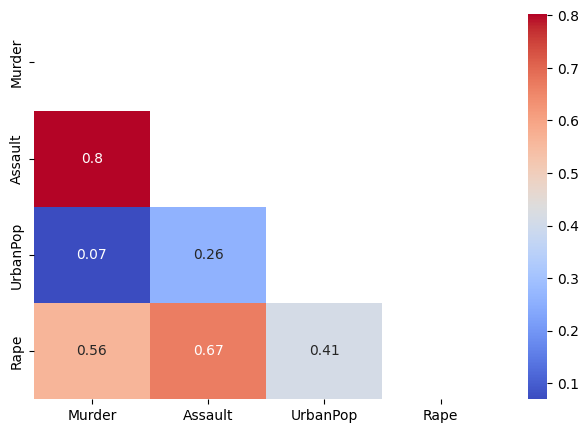

In [15]:
# X = df.copy()
states = X.index

# Create Correlation matrix
corr_df = X.corr()
labels = corr_df.columns

correlations = corr_df.corr()

# Plot correlation matrix
plt.figure(figsize=(7.5,5))
mask_ut=np.triu(np.ones(corr_df.shape)).astype(np.bool)
sns.heatmap(corr_df, mask=mask_ut, annot=True, cmap="coolwarm")

### Interpretating the correlation matrix

- **Murder** and **Assault** intuitively show **strong positive correlation** as these events often occur simultaneously.
- **Assault** and **Rape** intuitively show **strong positive correlation** as these events often occur simultaneously.
- **Murder** and **Rape** show a more **mild positive correlation** as these events frequently occur independently.
- **UrbanPop**  has a **slightly positive relationship** with **Rape**.
- **UrbanPop** is **weakly correlated** with both **Murder and Assault**.

The correlations supports the use of PCA to reduce dimensionality.


## Principal Component Analysis

In [24]:
# Initialise PCA
pca_full = PCA()

# Apply PCA to the scaled data
X_pca = pca_full.fit_transform(X_scaled_df)

X_pca_df = pd.DataFrame(
    X_pca,
    columns=[f'PC{i+1}' for i in range(X.shape[1])],
    index=X.index
)

X_pca_df.head()

,PC1,PC2,PC3,PC4
City,,,,
Alabama,0.99,-1.13,-0.44,-0.16
Alaska,1.95,-1.07,2.04,0.44
Arizona,1.76,0.75,0.05,0.83
Arkansas,-0.14,-1.12,0.11,0.18
California,2.52,1.54,0.60,0.34


In [25]:

#Create dataframe to display results
explained_variance = pd.DataFrame({
    "Principal Component": [f"PC{i}" for i in range(1, len(X.columns) + 1)],
    "Explained Variance Ratio": pca_full.explained_variance_ratio_,
    "Cumulative Variance Ratio": np.cumsum(pca_full.explained_variance_ratio_),
    "Eigenvalue": pca_full.explained_variance_
})

explained_variance

,Principal Component,Explained Variance Ratio,Cumulative Variance Ratio,Eigenvalue
0,PC1,0.62,0.62,2.53
1,PC2,0.25,0.87,1.01
2,PC3,0.09,0.96,0.36
3,PC4,0.04,1.00,0.18


##### Cumulative explained variance chart

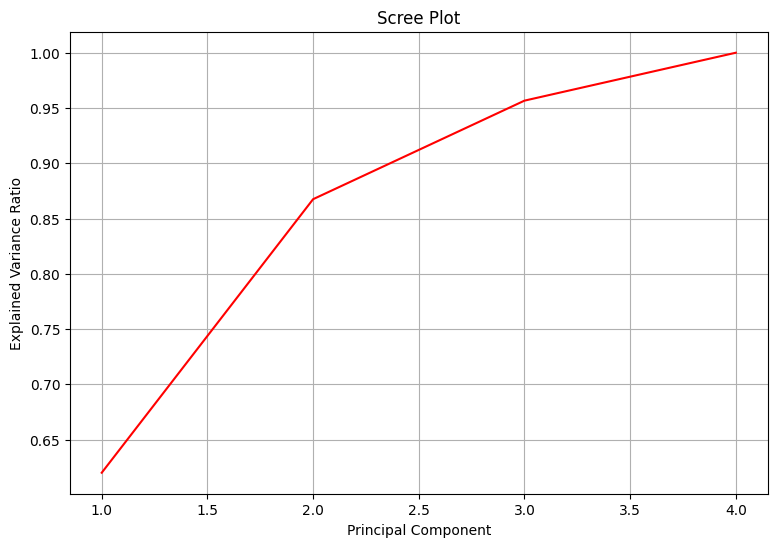

In [26]:
plt.figure(figsize=(9,6))

# Cumulative variance plot
plt.plot(range(1,len(pca_full.explained_variance_ratio_ )+1), np.cumsum(pca_full.explained_variance_ratio_), c='red')

# Add x,y label and chart title
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot')
plt.grid()

##### Cumulative variance chart

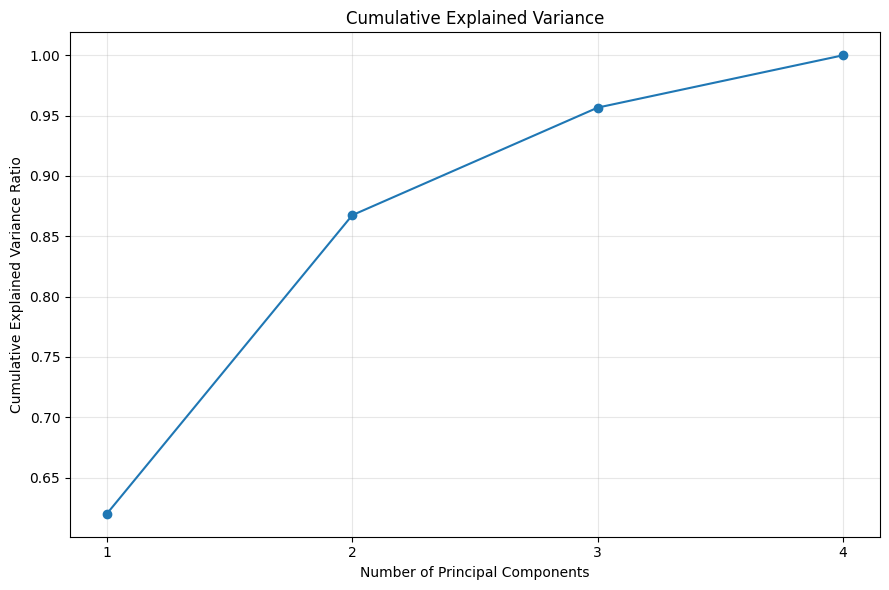

In [18]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(range(1, len(pca_full.explained_variance_ratio_) + 1), np.cumsum(pca_full.explained_variance_ratio_), marker="o")

ax.set_xlabel("Number of Principal Components")
ax.set_ylabel("Cumulative Explained Variance Ratio")
ax.set_title("Cumulative Explained Variance")
ax.set_xticks(range(1, len(pca_full.explained_variance_ratio_) + 1))
ax.grid(True, alpha=0.3)
plt.tight_layout()

#### Given that PC1 and PC2 have Eigenvalue magnitudes >1 and explain roughly 87% of the total variance, PC1 and PC2 are sufficient for our analysis

In [19]:
# Create dataframe to tabulate the PCA results
loadings = pd.DataFrame(
    pca_full.components_.T,
    index=X.columns,
    columns=[f"PC{i}" for i in range(1, len(X.columns) + 1)]
)

loadings

,PC1,PC2,PC3,PC4
Murder,0.54,-0.42,-0.34,-0.65
Assault,0.58,-0.19,-0.27,0.74
UrbanPop,0.28,0.87,-0.38,-0.13
Rape,0.54,0.17,0.82,-0.09


### Creating the Biplot

In [46]:
# Create biplot function
def biplot(score, coeff, labels=None, points=None):
    xs = score[:,0]
    ys = score[:,1]
    n = coeff.shape[0]
    scalex = 1.0/(xs.max() - xs.min())
    scaley = 1.0/(ys.max() - ys.min())

    fig, ax = plt.subplots()

    ax.scatter(xs * scalex,ys * scaley,s=5)

    for i in range(0,len(xs)):
        txt = states[i]
        ax.annotate(txt, (xs[i]* scalex, ys[i]* scaley), fontsize=8)

    for i in range(n):
        ax.arrow(0, 0, coeff[i,0], coeff[i,1],color = 'r', head_width=0.02, alpha = 0.5)
        if labels is None:
            ax.text(coeff[i,0]* 1.15, coeff[i,1] * 1.15, "Var"+str(i+1), color = 'green', ha = 'center', va = 'center')
        else:
            ax.text(coeff[i,0]* 1.15, coeff[i,1] * 1.15, labels[i], color = 'g', ha = 'center', va = 'center')
    
   
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title('PCA Biplot: First Two Principal Components')
    plt.grid()

    # Adapted from: https://ostwalprasad.github.io/machine-learning/PCA-using-python.html

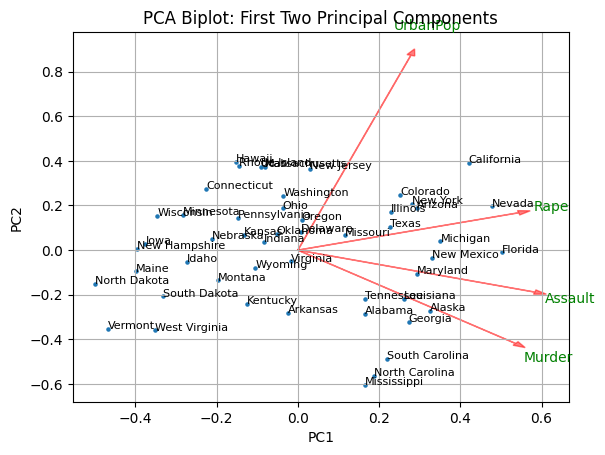

In [47]:
# Plot biplot
biplot(X_pca[:,0:2],np.transpose(pca_full.components_[0:2, :]),list(X.columns),list(X.index))

### Interpreting the Biplot

**Murder, Assault, and Rape** point in similar directions
**UrbanPop** points in a somewhat different direction

- States positioned far to the **right on PC1** (x-axis) tend to have **higher** overall violent crime levels  
- States **upward on PC2** (y-axis) tend to be more populated.

The biplot shows that PC1 captures crimes intensity, while PC2 separates states based on "UrbanPop vs crime" the various population sizes.




## Results & Interpretation
The clusters reveal distinct behavioral patterns that can be used for segmentation.

### Chooising number of principal components

In summary, **PC1** and **PC2** explains **87% of the cumulative variance** in the dataset, and **PC3 and PC4** explain the remainding **13% of the cumulative variance**

I will only choose PC1 and PC2 for further analysis

# KMeans and Hierarchial Clustering Methods

## Clustering Approach
Used K-Means and Hierarchical clustering to identify natural groupings in the data.

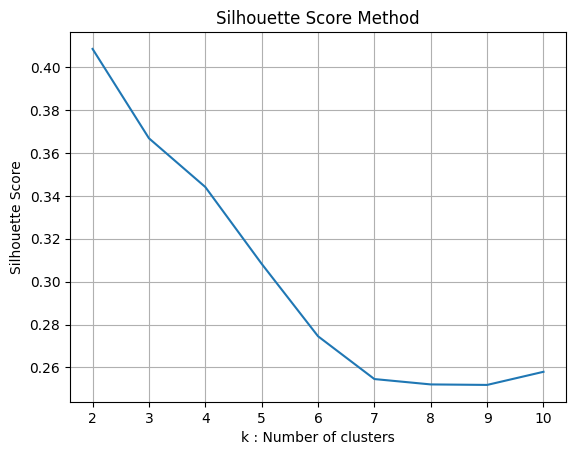

In [48]:
# Silhouette score method to find k: number of clusters
kmax = 10
sil = []
plt.plot()
for k in range(2, kmax+1):
    kmeans = KMeans(n_clusters=k, random_state=42, max_iter=500)
    kmeans.fit(X_pca)
    labels = kmeans.labels_
    sil.append(silhouette_score(X_pca, labels, metric='euclidean'))

sns.lineplot(x=range(2, kmax+1), y=sil)
plt.title('Silhouette Score Method')
plt.xlabel('k : Number of clusters')
plt.ylabel("Silhouette Score")
plt.grid(visible=True)
plt.show()

Based on the silhouette score method, the numbwer of clusters chosen should be K = 2.  

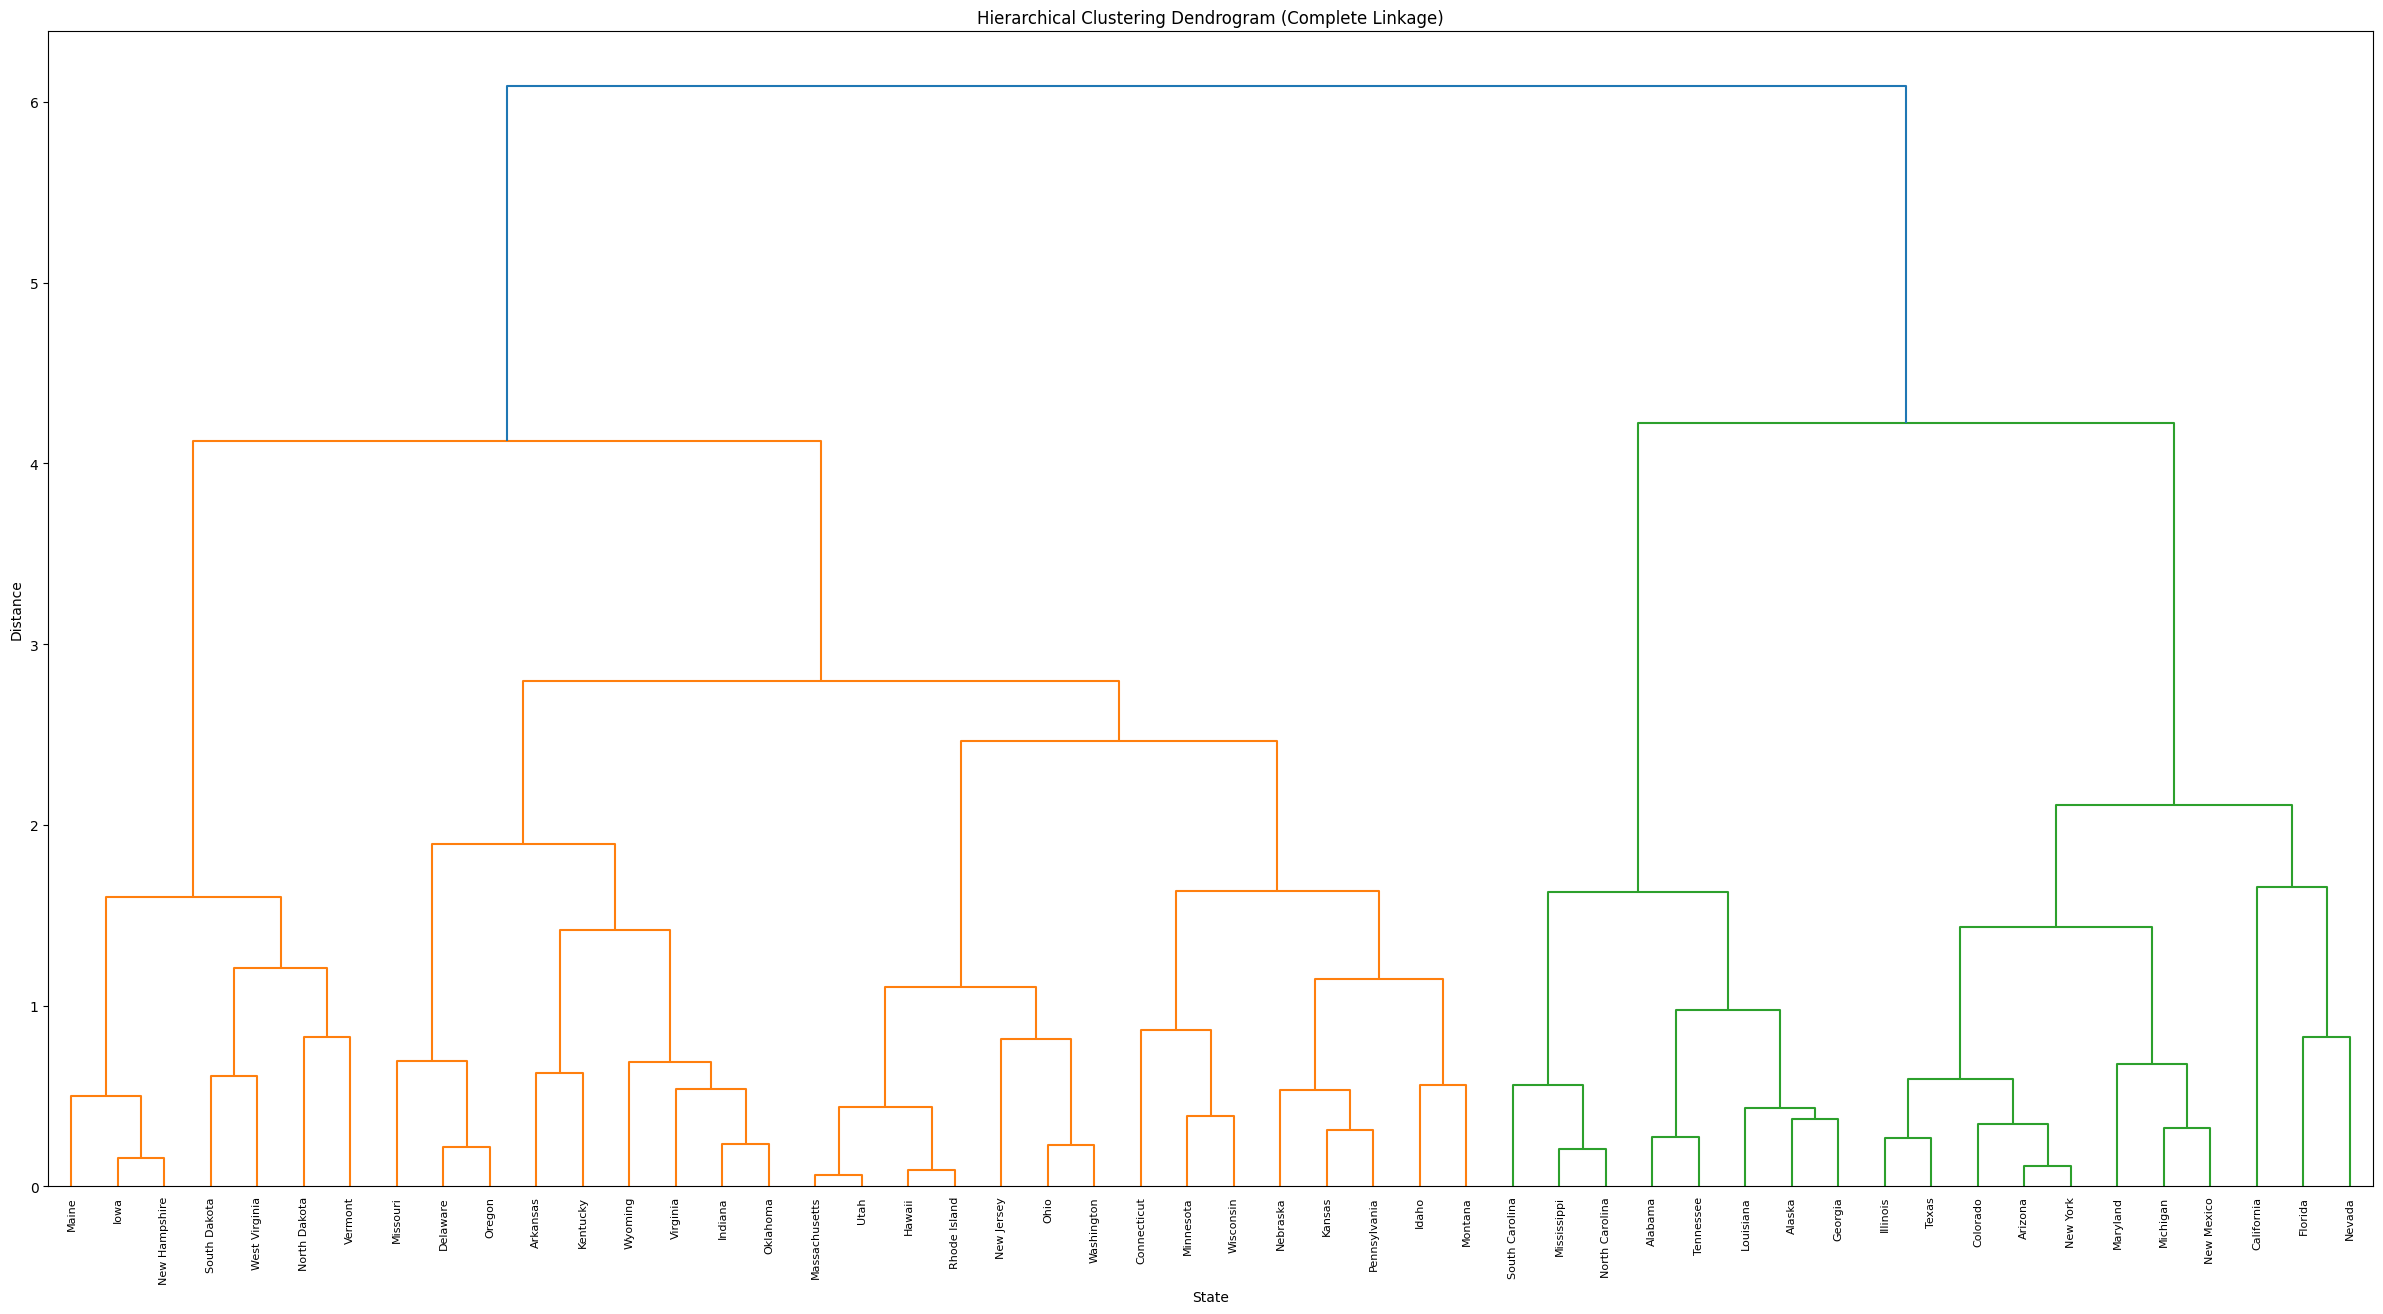

In [75]:
cluster_features = X_pca_df[['PC1', 'PC2']]

# Linkage method set to complete
linked = linkage(cluster_features, method='complete')

# Plot Dendrogram
plt.figure(figsize=(30, 15))
dendrogram(linked, labels=cluster_features.index.tolist(), leaf_rotation=90)
plt.title('Hierarchical Clustering Dendrogram (Complete Linkage)')
plt.xlabel('State')
plt.ylabel('Distance')
plt.show()

The dendogram confirms that **2 clusters** can be used for both techniques.


In [ ]:
# KMeans with n_clusters = 2
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(cluster_features)

# Hierarchical clustering
hierarchical = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage='complete')
# Form clusters
hierarchical_labels = hierarchical.fit_predict(cluster_features)

# Store labels in the PCA DataFrame for plotting
X_pca_df['KMeans_Cluster'] = kmeans_labels
X_pca_df['Hierarchical_Cluster'] = hierarchical_labels

# Also store labels in the original DataFrame for interpretation
df['KMeans_Cluster'] = kmeans_labels
df['Hierarchical_Cluster'] = hierarchical_labels

X_pca_df.head()

,PC1,PC2,PC3,PC4,KMeans_Cluster,Hierarchical_Cluster
City,,,,,,
Alabama,0.99,-1.13,-0.44,-0.16,1,0
Alaska,1.95,-1.07,2.04,0.44,1,0
Arizona,1.76,0.75,0.05,0.83,1,0
Arkansas,-0.14,-1.12,0.11,0.18,0,1
California,2.52,1.54,0.60,0.34,1,0


In [58]:
# Check model performance with the silhouette coefficient
score = silhouette_score(X_pca, kmeans_labels)
print(f"Silhouette Score: {score:.3f}")

Silhouette Score: 0.408


Text(0.5, 1.0, 'Hierarchical Clusters in PCA Space')

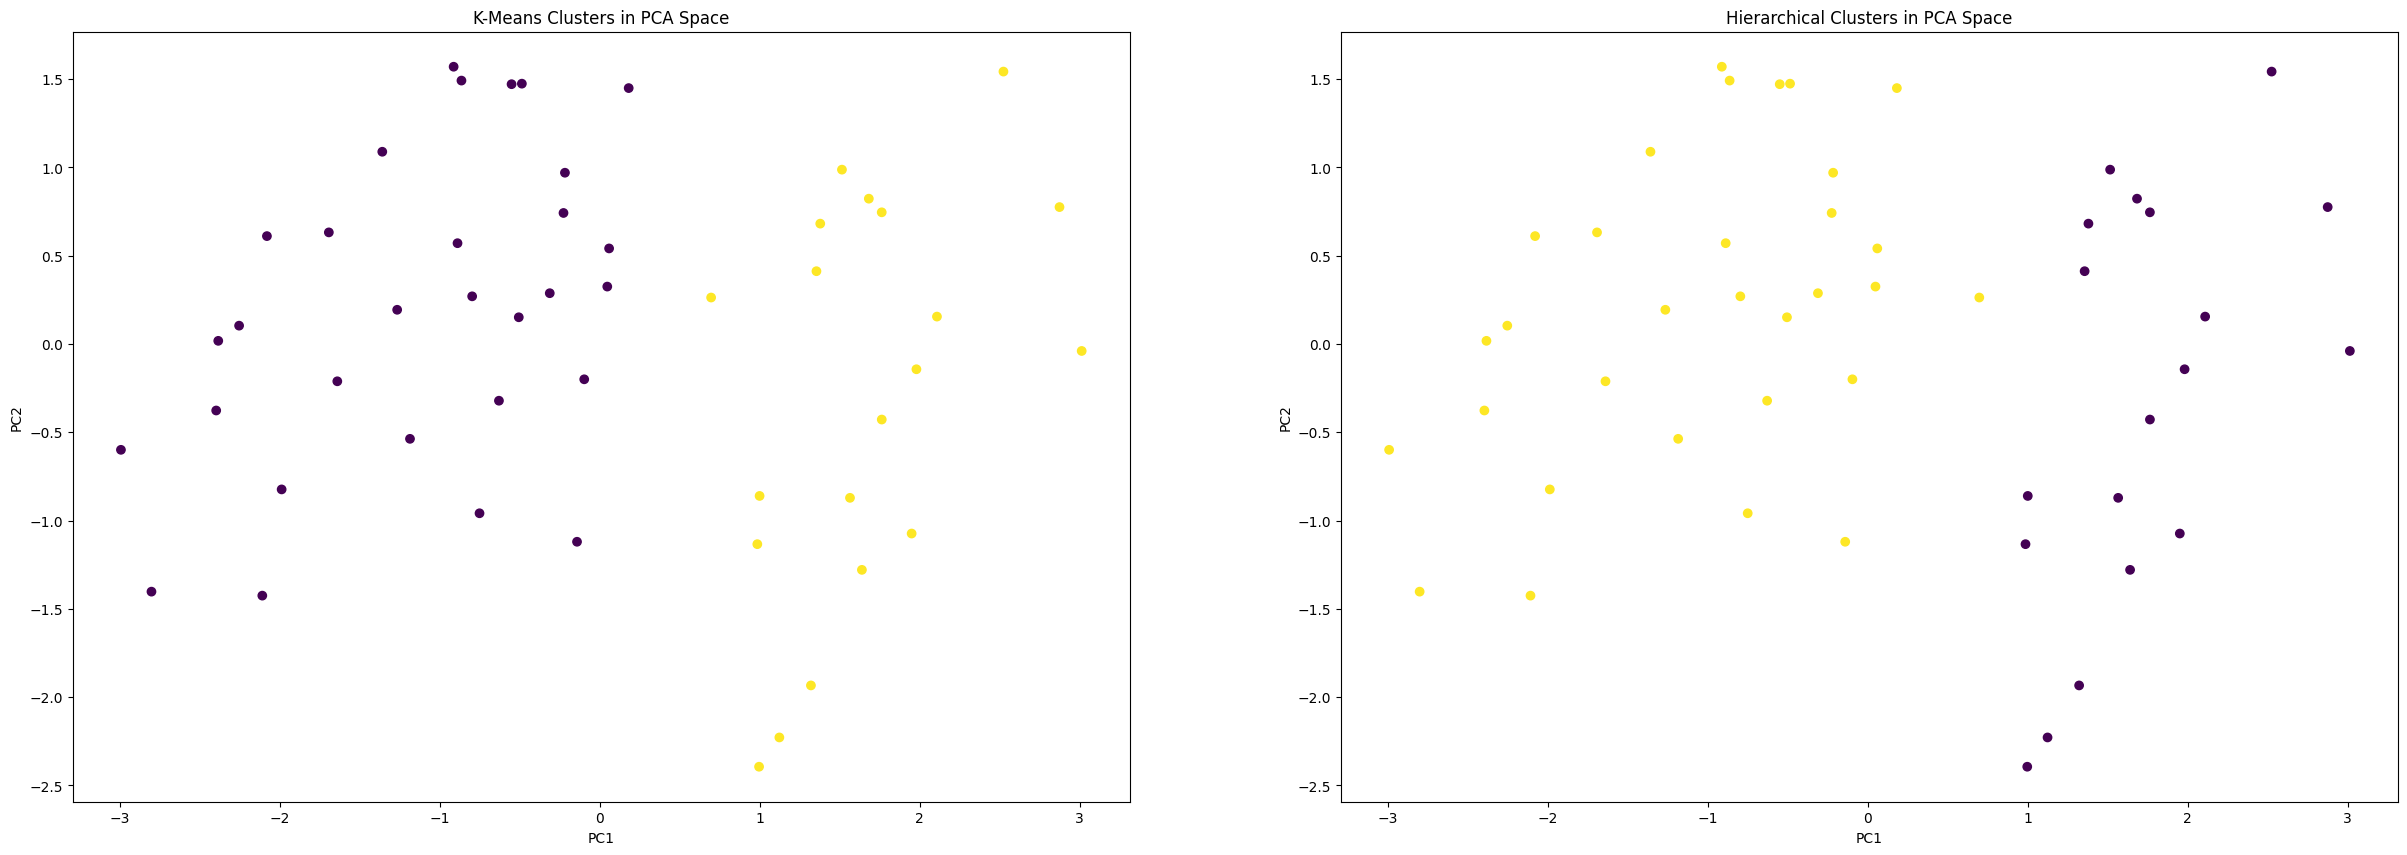

In [73]:
# Set figure size
plt.figure(figsize=(30,10))

#Create subplot and add title
plt.subplot(1,2,1)
plt.scatter(X_pca_df['PC1'], X_pca_df['PC2'], c=X_pca_df['KMeans_Cluster'])
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-Means Clusters in PCA Space')

#Create subplot and add title
plt.subplot(1,2,2)
plt.scatter(X_pca_df['PC1'], X_pca_df['PC2'], c=X_pca_df['Hierarchical_Cluster'])
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Hierarchical Clusters in PCA Space')

In [70]:
# Group by original feautures
kmeans_summary = df.groupby('KMeans_Cluster')[['Murder', 'Assault', 'UrbanPop', 'Rape']].mean()

# Diplsy summary
print("K-Means cluster means")
display(kmeans_summary)

K-Means cluster means


,Murder,Assault,UrbanPop,Rape
KMeans_Cluster,,,,
0,4.87,114.43,63.63,15.94
1,12.17,255.25,68.40,29.16


In [76]:
kmeans_members = df.groupby('KMeans_Cluster').apply(lambda x: list(x.index))
print("K-Means cluster members:")
display(kmeans_members)

K-Means cluster members:


KMeans_Cluster
0    [Arkansas, Connecticut, Delaware, Hawaii, Idah...
1    [Alabama, Alaska, Arizona, California, Colorad...
dtype: object

In [71]:
# Group by original feautures
hierarchical_summary = df.groupby('Hierarchical_Cluster')[['Murder', 'Assault', 'UrbanPop', 'Rape']].mean()

# Diplsy summary
print("Hierarchical cluster means")
display(hierarchical_summary)

Hierarchical cluster means


,Murder,Assault,UrbanPop,Rape
Hierarchical_Cluster,,,,
0,12.33,259.32,68.32,29.22
1,5.00,116.48,63.84,16.34


In [77]:
hierarchical_members = df.groupby('Hierarchical_Cluster').apply(lambda x: list(x.index))
print("Hierarchical cluster members:")
display(hierarchical_members)

Hierarchical cluster members:


Hierarchical_Cluster
0    [Alabama, Alaska, Arizona, California, Colorad...
1    [Arkansas, Connecticut, Delaware, Hawaii, Idah...
dtype: object

Text(0.5, 1.0, 'Correlation After PCA')

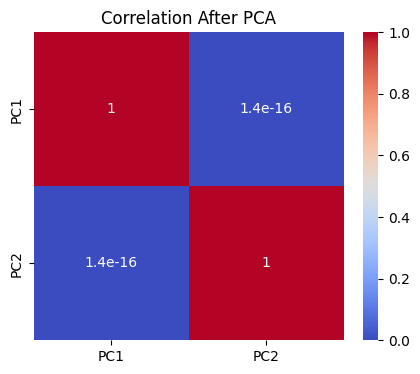

In [69]:
# Correlation of PCA components
corr_pca = X_pca_df[['PC1','PC2']].corr()

#Set figure size
plt.figure(figsize=(5,4))
sns.heatmap(corr_pca, annot=True, cmap='coolwarm')

#Add chart title
plt.title('Correlation After PCA')

### Interpretation of the clusters

The two clustering techniques produce **similar groupings**, which suggests that the broad structure of the dataset is stable.

#### Comparison of the two techniques
- **K-Means** and **Hierarchical Clustering** identify almost the same split in the data.
- The dominant pattern in the dataset is the separation between relatively **high-crime** and **low-crime** states.

## Conclusion

- The crime variables **Murder**, **Assault**, and **Rape** are positively correlated
- PCA showed that **PC1 and PC2** are sufficient as they explain roughly **87%** of the variance.
- The transformed components (PC1, PC2) are uncorrelated, confirming reduced noise and redundancy and the effictive use of PCA diminsion reduction
- The biplot indicates that the first component mainly captures overall violent crime, while the second component reflects a secondary contrast involving urbanisation and crime structure.
- Both **K-Means** and **Hierarchical Clustering** reveal a very similar division of states